# Young Midfielder Profiling & Scouting — Top 5 European Leagues (2024/25)

**Objective:** Identify and compare young midfielders (ages 21–26) across Europe's top five leagues using two distinct analytical frameworks:

1. **Deep-Lying Playmaker (DLP) similarity** — cosine similarity against a prototype player to find statistical lookalikes
2. **Defensive Midfielder (DM) composite scoring** — z-score ranking across ball-winning and defensive metrics

**Data source:** FBref 2024/25 season, all outfield players across the Premier League, La Liga, Bundesliga, Serie A, and Ligue 1.

**Minimum threshold:** 1,300 minutes played, to ensure sample size reliability.

## 1. Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

## 2. Load & Filter Data

We filter to pure midfielders (`Pos == "MF"`) aged 21–26 with at least 1,300 minutes played. The age bracket targets players past their developmental phase but before their peak years — a prime scouting window for clubs looking to buy before value peaks.

In [5]:
df = pd.read_csv('data/players_data_light-2024_2025.csv')

midfielders_df = (
    df[
        df["Pos"].str.contains("MF", na=False) &
        df["Age"].between(21, 26) &
        (df["Min"] >= 1300)
    ]
    .copy()
)

print(f"Qualifying midfielders: {midfielders_df.shape[0]}")
print(f"Competitions covered: {midfielders_df['Comp'].nunique()}")
midfielders_df[["Player", "Squad", "Comp", "Age", "Min"]].head(5)

Qualifying midfielders: 276
Competitions covered: 5


,Player,Squad,Comp,Age,Min
6,Himad Abdelli,Angers,fr Ligue 1,24.0,2842
15,Zakaria Aboukhlal,Toulouse,fr Ligue 1,24.0,1901
25,Tyler Adams,Bournemouth,eng Premier League,25.0,1965
29,Karim Adeyemi,Dortmund,de Bundesliga,22.0,1433
37,Oladapo Afolayan,St. Pauli,de Bundesliga,26.0,1639


## 3. Column Renaming

FBref exports use abbreviated or duplicated column names. We rename the key columns used in this analysis for clarity.

In [6]:
rename_map = {
    'cmp': 'Passes_cmp',
    'Att': 'Passes_Att',
    'Cmp%': 'Pass_Cmp%',
    '1/3': 'Passes_into_final_3rd',
    'PPA': 'Passes_into_penalty_area',
    'Def 3rd': 'Def_3rd_Tkl',
    'Mid 3rd': 'Mid_3rd_Tkl',
    'Att 3rd': 'Att_3rd_Tkl',
    'Lost': 'Tkl_Lost',
    'Blocks_stats_defense': 'Blocks',
    'Def 3rd_stats_possession': 'Def_3rd_Touches',
    'Mid 3rd_stats_possession': 'Mid_3rd_Touches',
    'Att 3rd_stats_possession': 'Att_3rd_Touches',
    'Att_stats_possession': 'Take_Ons_Att',
    'Succ': 'Succ_Take_Ons',
    'Succ%': 'Succ_Take_On%',
    'TotDist_stats_possession': 'Total_Carry_Distance',
    'PrgDist_stats_possession': 'Total_PrgDist',
    '1/3_stats_possession': 'Final_3rd_Carries',
    'Lost_stats_misc': 'Aerials_lost',
    'Won%': 'Aerials_Won%'
}

midfielders_df.rename(columns=rename_map, inplace=True)
print("Columns renamed successfully.")

Columns renamed successfully.


## 4. Per-90 Normalisation

Raw counts are converted to per-90-minute rates to account for differences in minutes played. A player who has made 10 more interceptions purely because they've played 400 more minutes should not rank above a player with a higher interception rate.

In [7]:
per90_cols = ["PrgP", "Touches", "PrgC", "Passes_Att", "Tkl", "Int", "Recov"]

for col in per90_cols:
    midfielders_df[col + "_per90"] = midfielders_df[col] / (midfielders_df["Min"] / 90)

print("Per-90 columns created:", [c + "_per90" for c in per90_cols])

Per-90 columns created: ['PrgP_per90', 'Touches_per90', 'PrgC_per90', 'Passes_Att_per90', 'Tkl_per90', 'Int_per90', 'Recov_per90']


---

## Part 1: Deep-Lying Playmaker (DLP) — Prototype Similarity

### Methodology

Rather than building a generic 'best playmaker' score, we use a **prototype-based similarity approach**. A real elite player is selected as the archetype, and all other players are ranked by how closely their statistical fingerprint matches his.

**Why cosine similarity?**  
Cosine similarity measures the angle between two vectors in feature space rather than their absolute distance. This means a player is ranked highly if they *profile like* the prototype — their relative strengths and weaknesses align — regardless of whether they play in a higher- or lower-volume system. This is more appropriate for positional profiling than Euclidean distance.

**Prototype: Vitinha (Paris Saint-Germain)**  
Vitinha represents the modern DLP archetype: high touch and pass volume, excellent completion rate, consistent progressive output, and enough defensive engagement to screen the backline. He was selected as the prototype because his role in PSG's build-up structure is well-defined and consistently reflected in his stats.

**Features used:**
| Feature | What it captures |
|---|---|
| `PrgP_per90` | How often the player advances play |
| `Touches_per90` | Overall involvement / ball magnetism |
| `PrgC_per90` | Carrying progression — dynamic playmaking |
| `Passes_Att_per90` | Passing volume |
| `Pass_Cmp%` | Ball retention / technical quality |
| `Int_per90` | Defensive reading — press trigger awareness |

In [8]:
dlp_features = [
    "PrgP_per90",
    "Touches_per90",
    "PrgC_per90",
    "Passes_Att_per90",
    "Pass_Cmp%",
    "Int_per90"
]

# Filter to pure MF position only and drop rows with missing features
dlp_df = (
    midfielders_df[midfielders_df["Pos"] == "MF"]
    .dropna(subset=dlp_features)
    .copy()
)

print(f"Players in DLP pool: {len(dlp_df)}")

Players in DLP pool: 121


### Cosine Similarity Against Vitinha

Features are standardised with `StandardScaler` before similarity is computed, so no single metric dominates due to scale differences.

In [9]:
# Extract Vitinha's feature vector as the prototype
dlp_prototype = (
    dlp_df[
        (dlp_df["Player"] == "Vitinha") &
        (dlp_df["Squad"] == "Paris S-G")
    ][dlp_features]
    .mean()
)

# Standardise the feature matrix and prototype vector
scaler = StandardScaler()
X_scaled = scaler.fit_transform(dlp_df[dlp_features])
proto_vec = scaler.transform(pd.DataFrame([dlp_prototype], columns=dlp_features))

# Compute cosine similarity and attach to dataframe
dlp_df["DLP_similarity"] = cosine_similarity(X_scaled, proto_vec).flatten()

# Display top 20 most similar players
dlp_df.sort_values("DLP_similarity", ascending=False)[
    ["Player", "Squad", "Comp", "Age", "Min", "DLP_similarity"]
].head(20)

,Player,Squad,Comp,Age,Min,DLP_similarity
2718,Vitinha,Paris S-G,fr Ligue 1,24.0,2042,1.000000
2506,Angelo Stiller,Stuttgart,de Bundesliga,23.0,2741,0.964020
2060,Pedri,Barcelona,es La Liga,21.0,2879,0.948941
1507,Manuel Locatelli,Juventus,it Serie A,26.0,2822,0.943258
811,Éderson,Atalanta,it Serie A,25.0,2881,0.918753
313,Adrian Bernabe,Parma,it Serie A,23.0,1453,0.849903
642,Lucas Da Cunha,Como,it Serie A,23.0,2613,0.835647
1640,Iván Martín,Girona,es La Liga,25.0,2039,0.815887
1553,Alexis Mac Allister,Liverpool,eng Premier League,25.0,2599,0.815394
1080,Mattéo Guendouzi,Lazio,it Serie A,25.0,3270,0.806336


### Case Study: Angelo Stiller vs Vitinha

**Angelo Stiller (Stuttgart)** emerges as the closest statistical match. The scatter plots below contextualise their profiles against the full DLP pool across two dimensions: playmaking output and build-up involvement.

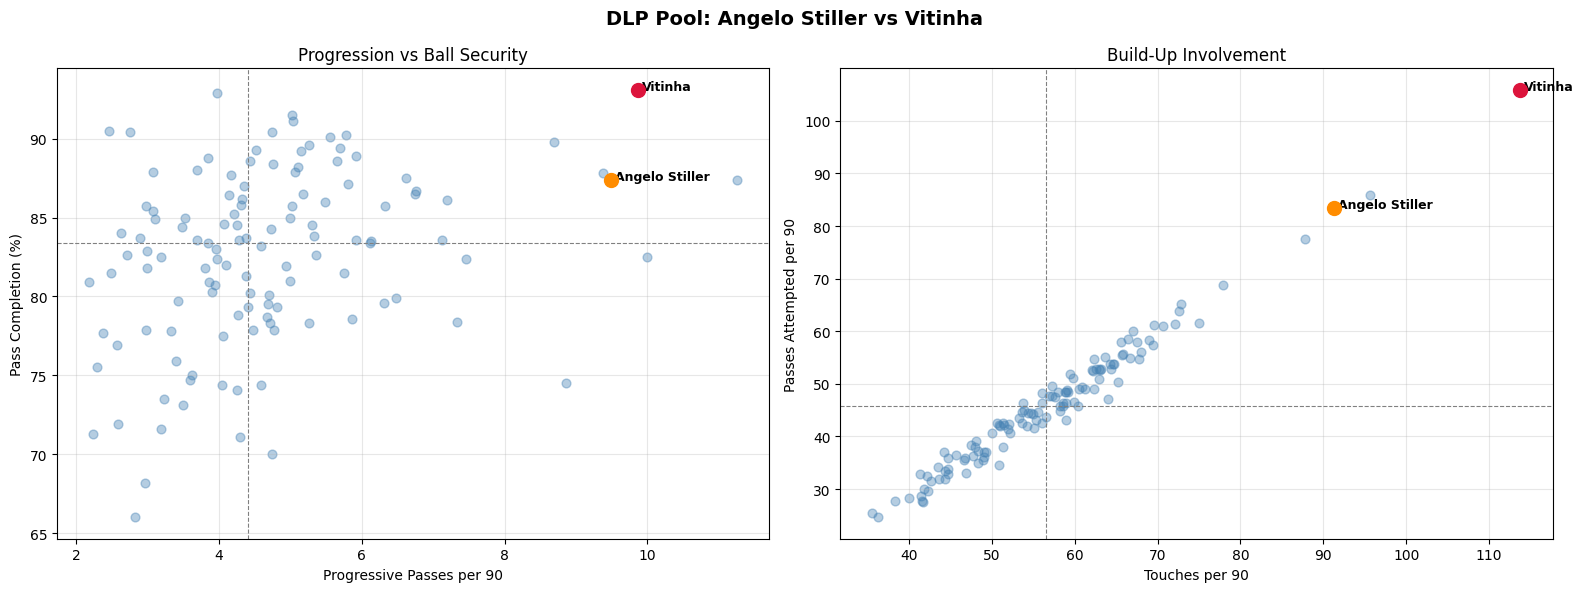

In [10]:
highlight_players = [
    ("Angelo Stiller", None),
    ("Vitinha", "Paris S-G")
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("DLP Pool: Angelo Stiller vs Vitinha", fontsize=14, fontweight='bold')

# Plot 1: Progression vs Completion
ax = axes[0]
ax.scatter(dlp_df["PrgP_per90"], dlp_df["Pass_Cmp%"], alpha=0.4, color='steelblue', s=40)
for name, squad in highlight_players:
    mask = dlp_df["Player"] == name
    if squad:
        mask &= dlp_df["Squad"] == squad
    row = dlp_df[mask].iloc[0]
    ax.scatter(row["PrgP_per90"], row["Pass_Cmp%"], s=100, zorder=5,
               color='crimson' if name == 'Vitinha' else 'darkorange')
    ax.text(row["PrgP_per90"] + 0.05, row["Pass_Cmp%"], name, fontsize=9, fontweight='bold')
ax.axvline(dlp_df["PrgP_per90"].median(), linestyle='--', color='grey', linewidth=0.8)
ax.axhline(dlp_df["Pass_Cmp%"].median(), linestyle='--', color='grey', linewidth=0.8)
ax.set_xlabel("Progressive Passes per 90")
ax.set_ylabel("Pass Completion (%)")
ax.set_title("Progression vs Ball Security")
ax.grid(True, alpha=0.3)

# Plot 2: Involvement
ax = axes[1]
ax.scatter(dlp_df["Touches_per90"], dlp_df["Passes_Att_per90"], alpha=0.4, color='steelblue', s=40)
for name, squad in highlight_players:
    mask = dlp_df["Player"] == name
    if squad:
        mask &= dlp_df["Squad"] == squad
    row = dlp_df[mask].iloc[0]
    ax.scatter(row["Touches_per90"], row["Passes_Att_per90"], s=100, zorder=5,
               color='crimson' if name == 'Vitinha' else 'darkorange')
    ax.text(row["Touches_per90"] + 0.5, row["Passes_Att_per90"], name, fontsize=9, fontweight='bold')
ax.axvline(dlp_df["Touches_per90"].median(), linestyle='--', color='grey', linewidth=0.8)
ax.axhline(dlp_df["Passes_Att_per90"].median(), linestyle='--', color='grey', linewidth=0.8)
ax.set_xlabel("Touches per 90")
ax.set_ylabel("Passes Attempted per 90")
ax.set_title("Build-Up Involvement")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Percentile Rank Radar: Angelo Stiller vs Vitinha

Metrics are converted to **percentile ranks** within the DLP pool, so each value represents where a player sits relative to all qualifying midfielders on that metric. This makes the radar directly interpretable: the outer edge = top of the pool, the centre = bottom.

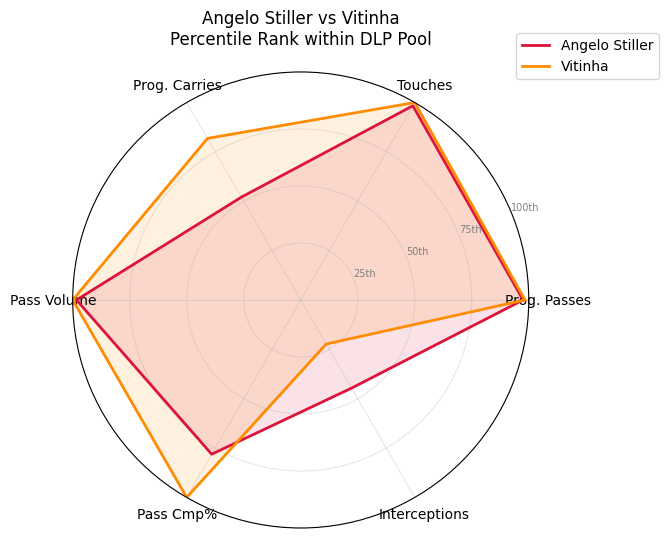

In [11]:
players_dlp = dlp_df[
    (dlp_df["Player"] == "Angelo Stiller") |
    ((dlp_df["Player"] == "Vitinha") & (dlp_df["Squad"] == "Paris S-G"))
].copy()

radar_pct = dlp_df[dlp_features].rank(pct=True)
players_radar = radar_pct.loc[players_dlp.index].copy()
players_radar["Player"] = players_dlp["Player"].values

labels = ["Prog. Passes", "Touches", "Prog. Carries", "Pass Volume", "Pass Cmp%", "Interceptions"]
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

colors = ['crimson', 'darkorange']
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, (_, row) in enumerate(players_radar.iterrows()):
    values = row[dlp_features].tolist() + [row[dlp_features].tolist()[0]]
    ax.plot(angles, values, linewidth=2, label=row["Player"], color=colors[i])
    ax.fill(angles, values, alpha=0.12, color=colors[i])

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25th', '50th', '75th', '100th'], fontsize=7, color='grey')
ax.set_title("Angelo Stiller vs Vitinha\nPercentile Rank within DLP Pool", pad=20, fontsize=12)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Part 2: Defensive Midfielder (DM) — Composite Z-Score Ranking

### Methodology

For the defensive midfielder archetype, a prototype similarity approach is less appropriate — DMs vary more in style (press-heavy vs positional) than DLPs, so no single player cleanly defines the archetype.

Instead, we use a **composite z-score** that directly rewards players who are above average across all five ball-winning and retention metrics simultaneously. The penalty term (`- Z_std`) reduces the score for players who are elite in one metric but weak in others, favouring well-rounded profiles.

```
DM_score = mean(Z_scores) - std(Z_scores)
```

**Features used:**
| Feature | What it captures |
|---|---|
| `Tkl_per90` | Tackling volume — proactive ball-winning |
| `Int_per90` | Defensive positioning and reading of play |
| `Recov_per90` | Loose ball recovery — work rate |
| `Tkl%` | Tackle efficiency — quality not just quantity |
| `Pass_Cmp%` | Retention after winning possession |

In [12]:
dm_features = [
    "Tkl_per90",
    "Int_per90",
    "Recov_per90",
    "Tkl%",
    "Pass_Cmp%"
]

dm_df = midfielders_df.dropna(subset=dm_features).copy()

# Z-score each feature
Z_dm = (dm_df[dm_features] - dm_df[dm_features].mean()) / dm_df[dm_features].std()

# Composite: reward high mean, penalise high variance across metrics
dm_df["DM_score"] = Z_dm.mean(axis=1) - Z_dm.std(axis=1)

print("Top 20 Defensive Midfielders (Composite Z-Score):")
dm_df.sort_values("DM_score", ascending=False)[
    ["Player", "Squad", "Comp", "Age", "Min", "DM_score"]
].head(20)

Top 20 Defensive Midfielders (Composite Z-Score):


,Player,Squad,Comp,Age,Min,DM_score
434,Moisés Caicedo,Chelsea,eng Premier League,22.0,3351,1.314497
124,André,Wolves,eng Premier League,23.0,2472,1.180229
1676,Azor Matusiwa,Rennes,fr Ligue 1,26.0,2078,1.147173
1793,Manu Morlanes,Mallorca,es La Liga,25.0,1338,1.023908
99,Sergi Altimira,Betis,es La Liga,22.0,1972,0.890669
43,Lucien Agoume,Sevilla,es La Liga,22.0,2114,0.839076
2011,Elisha Owusu,Auxerre,fr Ligue 1,26.0,2344,0.824418
2489,Anton Stach,Hoffenheim,de Bundesliga,25.0,2585,0.704001
2266,Nicolò Rovella,Lazio,it Serie A,22.0,2718,0.622898
248,Enzo Barrenechea,Valencia,es La Liga,23.0,2191,0.513759


### Top 10 Defensive Midfielders — Visualisations

The scatter plots below plot the full DM pool with the top 10 scorers highlighted, split across two pairs of metrics. Median reference lines divide each plot into quadrants.

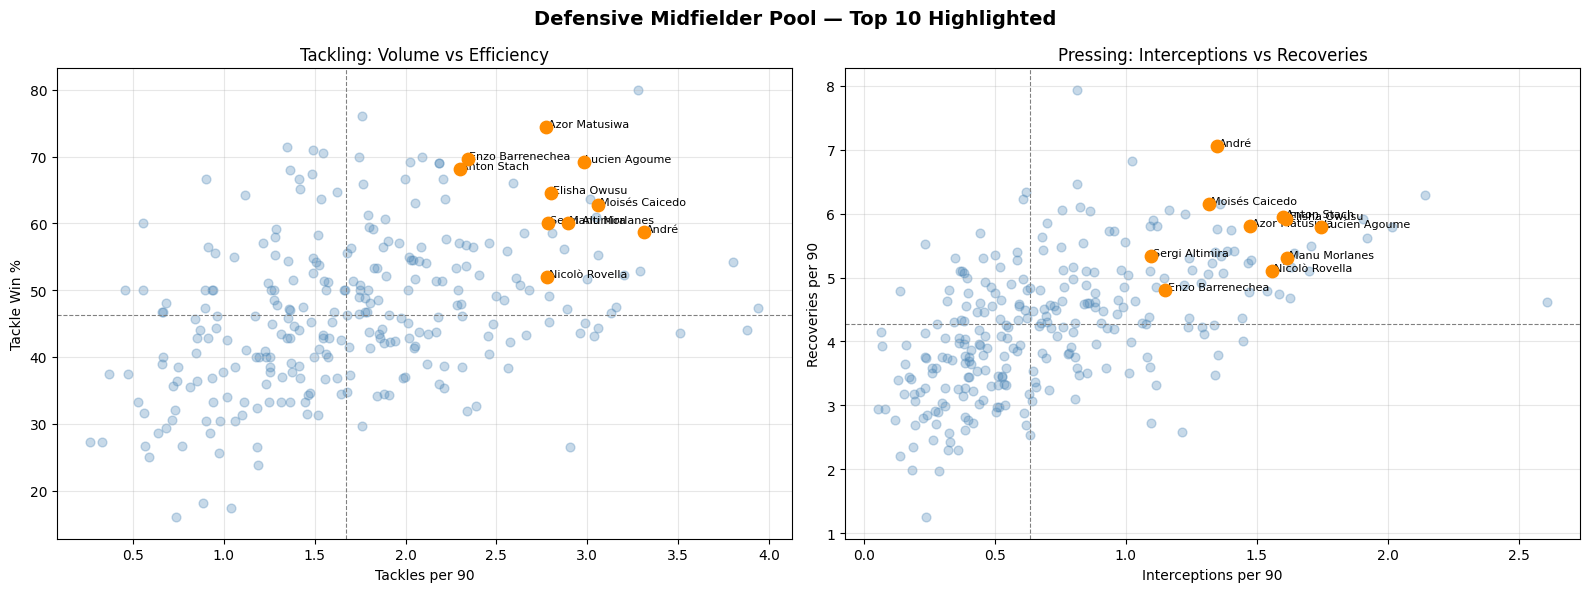

In [13]:
top10_dm = dm_df.sort_values("DM_score", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Defensive Midfielder Pool — Top 10 Highlighted", fontsize=14, fontweight='bold')

plot_configs = [
    ("Tkl_per90", "Tkl%", "Tackles per 90", "Tackle Win %", "Tackling: Volume vs Efficiency"),
    ("Int_per90", "Recov_per90", "Interceptions per 90", "Recoveries per 90", "Pressing: Interceptions vs Recoveries")
]

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, plot_configs):
    ax.scatter(dm_df[xcol], dm_df[ycol], alpha=0.3, color='steelblue', s=40)
    for _, row in top10_dm.iterrows():
        ax.scatter(row[xcol], row[ycol], color='darkorange', s=80, zorder=5)
        ax.text(row[xcol] + 0.01, row[ycol], row["Player"], fontsize=8, ha='left')
    ax.axvline(dm_df[xcol].median(), linestyle='--', color='grey', linewidth=0.8)
    ax.axhline(dm_df[ycol].median(), linestyle='--', color='grey', linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Case Study: Agoumé vs Caicedo vs André

Three players from different leagues and stylistic contexts are selected for a head-to-head radar comparison. Each value represents a percentile rank within the full DM pool.

- **Lucien Agoumé** (Inter Milan / Sevilla) — a progressive DM with strong recovery numbers
- **Moisés Caicedo** (Chelsea) — high-energy presser, elite tackle volume
- **André** (Fluminense / Wolverhampton) — positional DM, lower volume but efficient

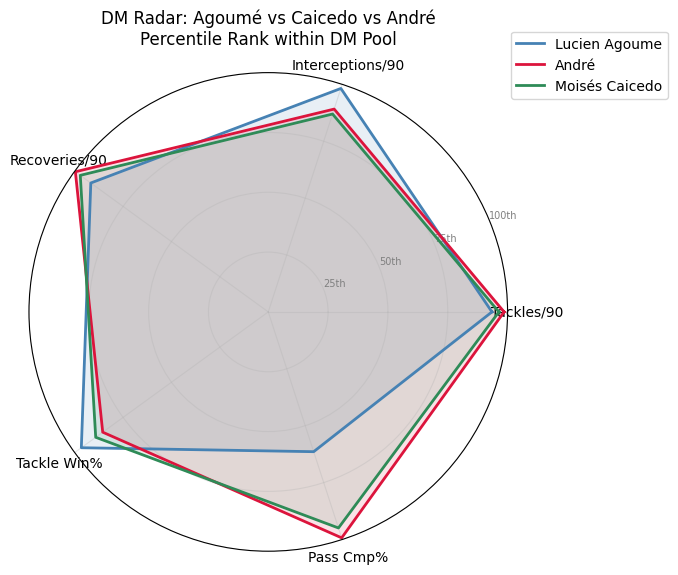

In [14]:
players_dm = dm_df[
    dm_df["Player"].isin(["Lucien Agoume", "Moisés Caicedo", "André"])
].copy()

radar_pct_dm = dm_df[dm_features].rank(pct=True)
players_radar_dm = radar_pct_dm.loc[players_dm.index].copy()
players_radar_dm["Player"] = players_dm["Player"].values

dm_labels = ["Tackles/90", "Interceptions/90", "Recoveries/90", "Tackle Win%", "Pass Cmp%"]
num_vars = len(dm_labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

colors_dm = ['steelblue', 'crimson', 'seagreen']
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, (_, row) in enumerate(players_radar_dm.iterrows()):
    values = row[dm_features].tolist() + [row[dm_features].tolist()[0]]
    ax.plot(angles, values, linewidth=2, label=row["Player"], color=colors_dm[i])
    ax.fill(angles, values, alpha=0.12, color=colors_dm[i])

ax.set_thetagrids(np.degrees(angles[:-1]), dm_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25th', '50th', '75th', '100th'], fontsize=7, color='grey')
ax.set_title("DM Radar: Agoumé vs Caicedo vs André\nPercentile Rank within DM Pool", pad=20, fontsize=12)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()